# EDA — Dataset de Trincas e Fissuras

Análise exploratória do dataset antes do treinamento.
Cobre: contagem, resoluções, formato dos labels, distribuição de classes e tamanho dos objetos.

In [1]:
import os
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

# Resolve o root do projeto independente de onde o kernel foi iniciado
_here = Path.cwd()
if _here.name == "notebooks":
    _root = _here.parent          # desafio2_trincas/
else:
    _root = _here                 # ja esta em desafio2_trincas/

IMG_DIR = _root.parent / "dataset" / "images"
LBL_DIR = _root.parent / "dataset" / "labels"
RESULTS_DIR = _root / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Confirma que os diretorios existem
assert IMG_DIR.exists(), f"Nao encontrado: {IMG_DIR}"
assert LBL_DIR.exists(), f"Nao encontrado: {LBL_DIR}"

print(f"Dataset : {IMG_DIR}")
print(f"Labels  : {LBL_DIR}")
print(f"Results : {RESULTS_DIR}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Dataset : C:\Users\Carla Batista\Desktop\Desafio-2\dataset\images
Labels  : C:\Users\Carla Batista\Desktop\Desafio-2\dataset\labels
Results : C:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results


## 1. Contagem e extensões

In [2]:
images = sorted(IMG_DIR.glob('*.jpg')) + sorted(IMG_DIR.glob('*.png'))
labels = sorted(LBL_DIR.glob('*.txt'))

img_stems = {p.stem for p in images}
lbl_stems = {p.stem for p in labels}

print(f'Imagens : {len(images)}')
print(f'Labels  : {len(labels)}')
print(f'Pares   : {len(img_stems & lbl_stems)}')
print(f'Órfãos img: {len(img_stems - lbl_stems)}')
print(f'Órfãos lbl: {len(lbl_stems - img_stems)}')

Imagens : 1551
Labels  : 1551
Pares   : 1551
Órfãos img: 0
Órfãos lbl: 0


## 2. Resolução das imagens

In [3]:
from collections import Counter

sample = random.sample(images, min(200, len(images)))
resolutions = Counter()
for p in sample:
    img = Image.open(p)
    resolutions[img.size] += 1

print('Resoluções encontradas (amostra de 200):')
for res, cnt in resolutions.most_common():
    print(f'  {res[0]}x{res[1]}: {cnt} imagens')

Resoluções encontradas (amostra de 200):
  2560x1440: 200 imagens


## 3. Análise dos labels — formato e classes

In [4]:
class_counts   = Counter()
obj_per_image  = []
point_counts   = []
bbox_widths    = []
bbox_heights   = []
aspect_ratios  = []   # largura / altura da bbox derivada do polígono

for lbl_path in labels:
    lines = [l.strip() for l in lbl_path.read_text().splitlines() if l.strip()]
    obj_per_image.append(len(lines))
    for line in lines:
        parts = line.split()
        cls   = int(parts[0])
        class_counts[cls] += 1
        coords = np.array(parts[1:], dtype=float)
        n_pts  = len(coords) // 2
        point_counts.append(n_pts)
        xs = coords[0::2]
        ys = coords[1::2]
        w  = xs.max() - xs.min()
        h  = ys.max() - ys.min()
        bbox_widths.append(w)
        bbox_heights.append(h)
        aspect_ratios.append(w / h if h > 0 else 0)

print('Classes:', dict(class_counts))
print(f'\nObjetos por imagem:')
print(f'  min={min(obj_per_image)}  max={max(obj_per_image)}  média={np.mean(obj_per_image):.2f}')
print(f'\nPontos por polígono:')
print(f'  min={min(point_counts)}  max={max(point_counts)}  média={np.mean(point_counts):.1f}')
print(f'\nTamanho normalizado das bboxes:')
print(f'  largura  — min={min(bbox_widths):.3f}  max={max(bbox_widths):.3f}  média={np.mean(bbox_widths):.3f}')
print(f'  altura   — min={min(bbox_heights):.3f}  max={max(bbox_heights):.3f}  média={np.mean(bbox_heights):.3f}')

Classes: {0: 2056}

Objetos por imagem:
  min=1  max=18  média=1.33

Pontos por polígono:
  min=4  max=796  média=135.0

Tamanho normalizado das bboxes:
  largura  — min=0.004  max=1.000  média=0.346
  altura   — min=0.006  max=1.000  média=0.608


## 4. Distribuição de objetos por imagem

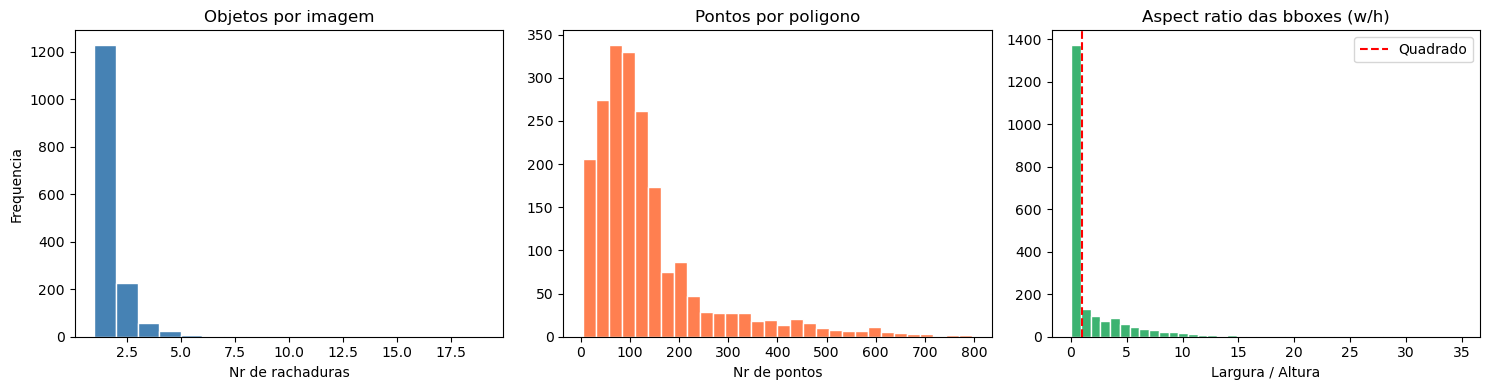

Salvo em: C:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_distributions.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(obj_per_image, bins=range(1, max(obj_per_image)+2), color='steelblue', edgecolor='white')
axes[0].set_title('Objetos por imagem')
axes[0].set_xlabel('Nr de rachaduras')
axes[0].set_ylabel('Frequencia')

axes[1].hist(point_counts, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Pontos por poligono')
axes[1].set_xlabel('Nr de pontos')

axes[2].hist(aspect_ratios, bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Aspect ratio das bboxes (w/h)')
axes[2].set_xlabel('Largura / Altura')
axes[2].axvline(1.0, color='red', linestyle='--', label='Quadrado')
axes[2].legend()

plt.tight_layout()
out = RESULTS_DIR / 'eda_distributions.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 5. Mapa de calor dos centros das bboxes

Revela se há viés de posição (ex.: trincas concentradas no centro das imagens).

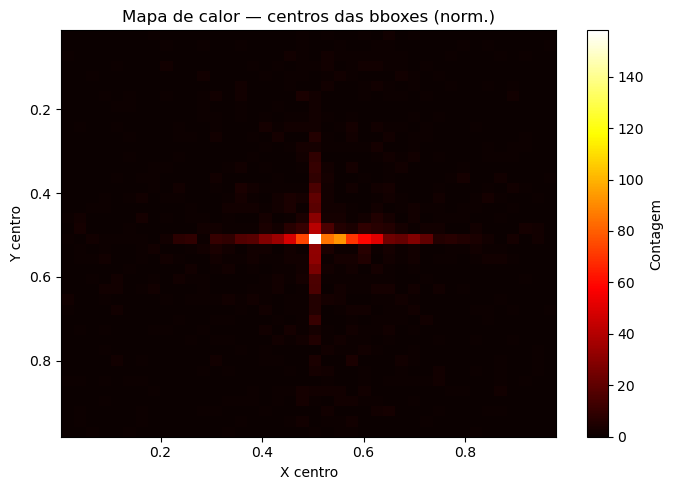

Salvo em: C:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_heatmap.png


In [6]:
cx_list = []
cy_list = []

for lbl_path in labels:
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        coords = np.array(parts[1:], dtype=float)
        xs = coords[0::2]
        ys = coords[1::2]
        cx_list.append((xs.max() + xs.min()) / 2)
        cy_list.append((ys.max() + ys.min()) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(cx_list, cy_list, bins=40, cmap='hot')
plt.colorbar(h[3], ax=ax, label='Contagem')
ax.set_title('Mapa de calor — centros das bboxes (norm.)')
ax.set_xlabel('X centro')
ax.set_ylabel('Y centro')
ax.invert_yaxis()
plt.tight_layout()
out = RESULTS_DIR / 'eda_heatmap.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 6. Scatter: largura × altura das bboxes

Trincas costumam ser objetos finos e alongados — esperamos pontos concentrados próximos aos eixos.

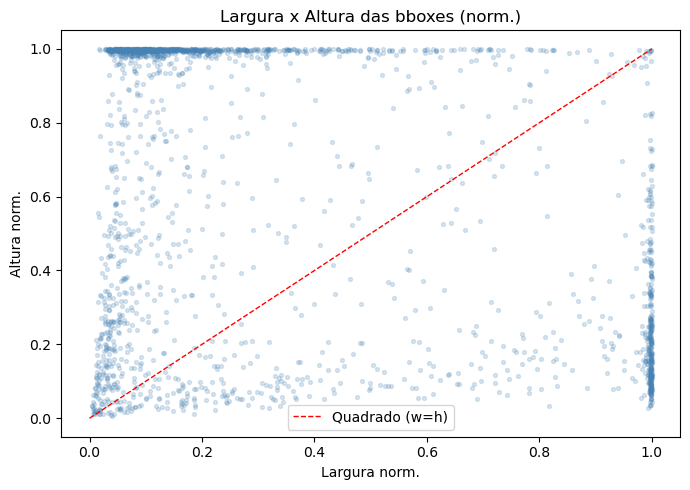

Salvo em: C:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_bbox_scatter.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bbox_widths, bbox_heights, alpha=0.2, s=8, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Quadrado (w=h)')
ax.set_title('Largura x Altura das bboxes (norm.)')
ax.set_xlabel('Largura norm.')
ax.set_ylabel('Altura norm.')
ax.legend()
plt.tight_layout()
out = RESULTS_DIR / 'eda_bbox_scatter.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 7. Visualização de amostras com polígonos sobrepostos

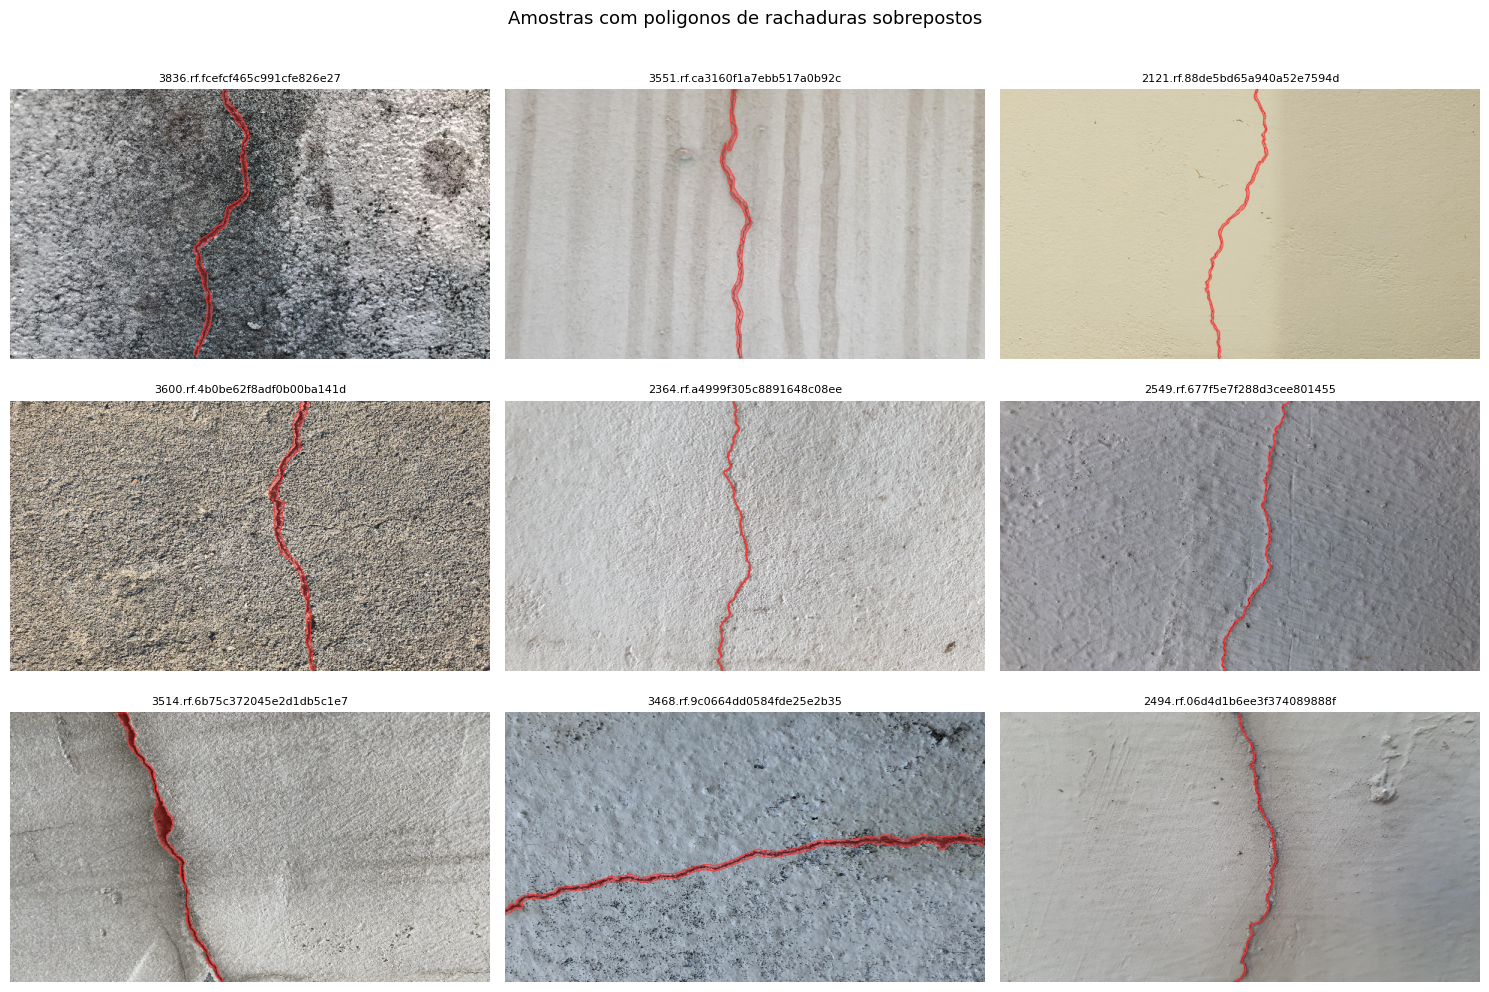

Salvo em: C:\Users\Carla Batista\Desktop\Desafio-2\desafio2_trincas\results\eda_samples.png


In [8]:
def draw_polygons(img_path: Path, lbl_path: Path) -> np.ndarray:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    overlay = img.copy()

    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        coords = np.array(parts[1:], dtype=float)
        pts = coords.reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = pts.astype(np.int32)
        cv2.fillPoly(overlay, [pts], color=(255, 50, 50))
        cv2.polylines(img, [pts], isClosed=True, color=(255, 50, 50), thickness=3)

    return cv2.addWeighted(overlay, 0.35, img, 0.65, 0)


stems = sorted(img_stems & lbl_stems)
sample_stems = random.sample(stems, 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, stem in zip(axes.flat, sample_stems):
    vis = draw_polygons(IMG_DIR / f'{stem}.jpg', LBL_DIR / f'{stem}.txt')
    vis_small = cv2.resize(vis, (640, 360))
    ax.imshow(vis_small)
    ax.set_title(stem[:30], fontsize=8)
    ax.axis('off')

plt.suptitle('Amostras com poligonos de rachaduras sobrepostos', fontsize=13, y=1.01)
plt.tight_layout()
out = RESULTS_DIR / 'eda_samples.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Salvo em: {out}')

## 8. Resumo — decisões tomadas com base no EDA

| Observação | Impacto / Decisão |
|---|---|
| Labels em formato YOLO-seg (polígonos) | Usar `yolo11n-seg.pt` — segmentação de instâncias |
| 1 única classe (`rachadura`) | `nc=1` no `data.yaml` |
| Polígonos com até 212 pontos (média ~72) | Rachaduras têm formato irregular — bbox seria imprecisa |
| 1551 imagens, todas 2560×1440 | Dataset pequeno-médio; `imgsz=640` no treino |
| Média 1.33 objetos/imagem | Dataset relativamente simples; overfitting é risco |
| Split 70/20/10 com seed 42 | Val com 310 imgs dá mAP confiável |